# Langkah 1: Mengunduh dan Membaca Dataset Newyork Taxi Trip Data

## 1.1 Import Library

In [ ]:
!pip install spark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for spark: filename=spark-0.2.1-py3-none-any.whl size=58748 sha256=1246694f21962258d26ee5777b6dd865f2bb1975704f71d0c6471fb92a094e73
  Stored in directory: /root/.cache/pip/wheels/67/c2/7c/a53325365fba358ffff35af84a2e14cf88c18052f88acfa5f0
Successfully built spark


In [ ]:
# Untuk pengolahan data dan pemrosesan file
import os
import pandas as pd
import numpy as np

In [ ]:
# Untuk PySpark session
from pyspark.sql import SparkSession

# Import fungsi-fungsi yang digunakan dalam transformasi dan agregasi
from pyspark.sql.functions import col, year, month, dayofweek, hour, unix_timestamp, count, sum, avg, when, isnull, rank, to_date
from pyspark.sql import functions as F

# Untuk window functions
from pyspark.sql.window import Window

# Untuk memproses data menggunakan MLlib
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression

# Untuk streaming (jika menggunakan Spark Streaming)
from pyspark.streaming import StreamingContext

## 1.2 Mengunduh Dataset

In [ ]:
from google.colab import files

files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d microize/newyork-yellow-taxi-trip-data-2020-2019

Dataset URL: https://www.kaggle.com/datasets/microize/newyork-yellow-taxi-trip-data-2020-2019
License(s): ODbL-1.0
 94% 1.69G/1.81G [00:11<00:02, 41.1MB/s]
100% 1.81G/1.81G [00:11<00:00, 162MB/s] 


In [ ]:
!unzip /content/newyork-yellow-taxi-trip-data-2020-2019.zip -d /content/

Archive:  /content/newyork-yellow-taxi-trip-data-2020-2019.zip
  inflating: /content/taxi+_zone_lookup.csv  
  inflating: /content/taxi_zones/taxi_zones.dbf  
  inflating: /content/taxi_zones/taxi_zones.prj  
  inflating: /content/taxi_zones/taxi_zones.sbn  
  inflating: /content/taxi_zones/taxi_zones.sbx  
  inflating: /content/taxi_zones/taxi_zones.shp  
  inflating: /content/taxi_zones/taxi_zones.shp.xml  
  inflating: /content/taxi_zones/taxi_zones.shx  
  inflating: /content/yellow_tripdata_2019-01.csv  
  inflating: /content/yellow_tripdata_2019-02.csv  
  inflating: /content/yellow_tripdata_2019-03.csv  
  inflating: /content/yellow_tripdata_2019-04.csv  
  inflating: /content/yellow_tripdata_2019-05.csv  
  inflating: /content/yellow_tripdata_2019-06.csv  
  inflating: /content/yellow_tripdata_2019-07.csv  
  inflating: /content/yellow_tripdata_2019-08.csv  
  inflating: /content/yellow_tripdata_2019-09.csv  
  inflating: /content/yellow_tripdata_2019-10.csv  
  inflating: /con

In [ ]:
from pyspark.sql import SparkSession

# Membuat SparkSession
spark = SparkSession.builder \
    .appName("Newyork Taxi Trip Data") \
    .getOrCreate()

# Membaca dataset CSV ke dalam DataFrame PySpark
df_taxi2019_01 = spark.read.csv("/content/yellow_tripdata_2019-01.csv", header=True, inferSchema=True)
df_taxi2020_06 = spark.read.csv("/content/yellow_tripdata_2020-06.csv", header=True, inferSchema=True)

# concate dataframe df_taxi2019_01 and df_taxi2020_06
df_taxi = df_taxi2019_01.unionByName(df_taxi2020_06)

# Menampilkan skema dan beberapa baris pertama
df_taxi.printSchema()
df_taxi.show(10)

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+---

Penjelasan Kolom
* VendorID: ID vendor taksi
* tpep_pickup_datetime: Tanggal dan waktu saat argo dinyalakan
* tpep_dropoff_datetime: Tanggal dan waktu saat argo dimatikan
* passenger_count: Jumlah penumpang di dalam taksi
* trip_distance: Jarak tempuh perjalanan (mil)
* RatecodeID: Kode tarif akhir yang berlaku di akhir perjalanan.
** 1 = Tarif standar
** 2 = JFK (perjalanan antara Manhattan dan Bandara JFK)
** 3 = Newark (perjalanan ke Bandara Internasional Newark-Liberty)
** 4 = Nassau or Westchester (perjalanan ke Kabupaten Westchester dan Nassau)
** 5 = Negotiated fare (tarif tetap yang disepakati untuk perjalanan di luar NYC)
** 6 = Group ride
* store_and_fwd_flag: Apakah catatan perjalanan disimpan dalam memori kendaraan sebelum dikirim ke vendor
* PULocationID: Zona argo taksi dinyalakan
* DOLocationID: Zona argo taksi dimatikan
* payment_type: Kode numerik yang menunjukkan bagaimana penumpang membayar perjalanan
** 1 = Kartu kredit
** 2 = Tunai
** 3 = Bebas biaya
** 4 = Sengketa
** 5 = Tidak diketahui
** 6 = Perjalanan dibatalkan
* fare_amount: Tarif waktu dan jarak dihitung dengan argo ($)

* extra: Biaya tambahan ($)

* mta_tax: Pajak MTA ($)

* tip_amount: Jumlah tip ($)

* tolls_amount: Biaya tol ($)

* improvement_surcharge: Biaya perbaikan ($)

* total_amount: Jumlah total yang dibebankan kepada penumpang ($)

* congestion_surcharge: Biaya kemacetan ($)

In [ ]:
# Menampilkan statistik deskriptif untuk dataset asli
df_taxi.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+-------------------+------------------+------------------+---------------------+------------------+--------------------+
|summary|          VendorID|   passenger_count|     trip_distance|        RatecodeID|store_and_fwd_flag|      PULocationID|     DOLocationID|       payment_type|       fare_amount|             extra|            mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|congestion_surcharge|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+-------------------+------------------+------------------+---------------------+------------------+--------------------+
|  count|           8166835|           8

Penjelasan
* count: Jumlah baris yang dihitung
* mean: nilai rata-rata
* stddev: standar deviasi
* min: nilai minimal
* max: nilai maksimal

# Langkah 2: Menyaring dan Membersihkan Data

Data yang hilang dapat memengaruhi analisis. Oleh karena itu, kita harus memeriksa dan menangani nilai null.

## 2.1 Memeriksa Nilai Null (Missing Values)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|   50717|                   0|                    0|          50717|            0|     50717|             50717|           0|           0|       50717|          0|    0|      0|         0|           0|                    0

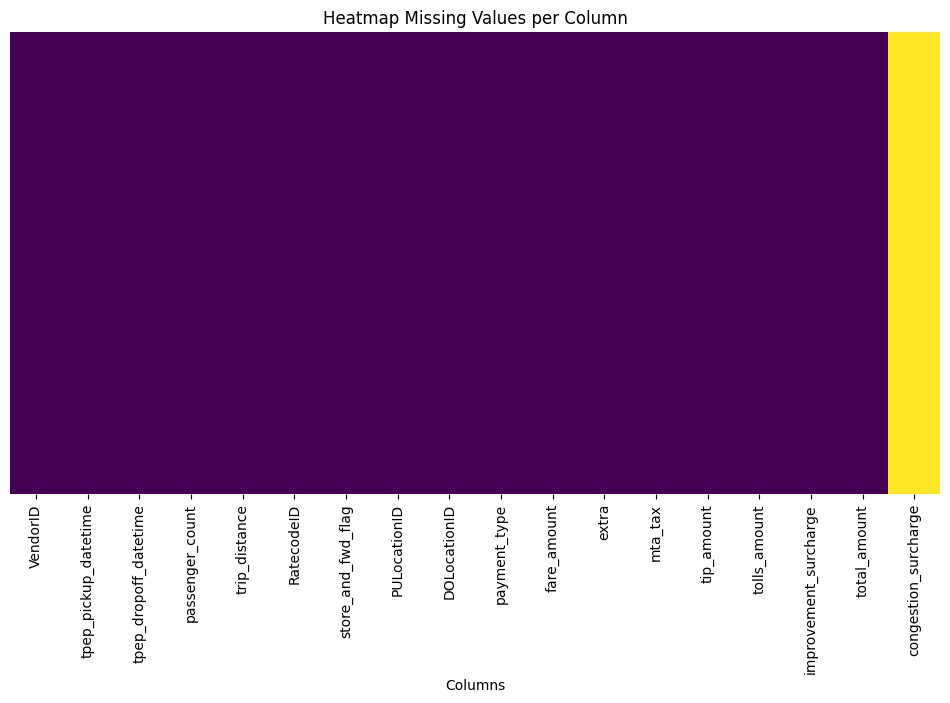

In [ ]:
from pyspark.sql.functions import count, when, isnull
import seaborn as sns
import matplotlib.pyplot as plt

# Mengecek jumlah nilai null di setiap kolom
df_taxi.select([count(when(isnull(c), c)).alias(c) for c in df_taxi.columns]).show()

df_missing = df_taxi.limit(100000).toPandas()

plt.figure(figsize=(12, 6))
sns.heatmap(df_missing.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Heatmap Missing Values per Column")
plt.xlabel("Columns")
plt.show()

Setelah memeriksa nilai null, kita dapat menghapus baris atau kolom yang mengandung nilai null.

## 2.2 Menghapus Baris dengan Nilai Null

In [ ]:
# Mengahpus kolom congestion_surcharge
df_taxi_clean = df_taxi.drop("congestion_surcharge")

# Menghapus baris yang memiliki nilai null pada setiap kolom
df_taxi_clean = df_taxi_clean.dropna()

# Menampilkan beberapa baris setelah pembersihan
df_taxi_clean.show(10)
df_taxi_clean.describe().show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|              1|          1.5|         1|                 N|         151|         239|           1|        7.0|  0.5|    0.5|      1.65|         0.0|                  0.3|        9.95|
|       1| 2019-01-01 00:59:47|  2019-01-01 01:1

## 2.3 Menerapkan Min dan Max untuk Standarisasi

In [ ]:
# Filter kolom
df_taxi_clean = df_taxi_clean.filter(
    (df_taxi["passenger_count"] > 0) &
    (df_taxi["trip_distance"] > 0) & (df_taxi["trip_distance"] <= 500) &
    (df_taxi["RatecodeID"] <= 6) &
    (df_taxi["fare_amount"] > 0) &
    (df_taxi["extra"] >= 0) &
    (df_taxi["mta_tax"] >= 0) &
    (df_taxi["tip_amount"] >= 0) &
    (df_taxi["tolls_amount"] >= 0) &
    (df_taxi["improvement_surcharge"] >= 0) &
    (df_taxi["total_amount"] > 0)
)

df_taxi_clean.describe().show()

+-------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-----------------+------------------+------------------+--------------------+------------------+-------------------+---------------------+------------------+
|summary|          VendorID|   passenger_count|     trip_distance|         RatecodeID|store_and_fwd_flag|      PULocationID|      DOLocationID|     payment_type|       fare_amount|             extra|             mta_tax|        tip_amount|       tolls_amount|improvement_surcharge|      total_amount|
+-------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+-----------------+------------------+------------------+--------------------+------------------+-------------------+---------------------+------------------+
|  count|           7958541|           7958541|           7958541|            7958541|           

In [ ]:
# Menghitung jumlah baris sebelum dan setelah pembersihan
print("Jumlah baris sebelum pembersihan:", df_taxi.count())
print("Jumlah baris setelah pembersihan:", df_taxi_clean.count())

Jumlah baris sebelum pembersihan: 8217552
Jumlah baris setelah pembersihan: 7958541


## 2.4 Perbandingan Statistik Deskriptif

Untuk memberikan gambaran yang lebih jelas tentang perbedaan data sebelum dan setelah pembersihan, kita dapat membandingkan statistik deskriptif.

In [ ]:
# Statistik deskriptif sebelum pembersihan (hanya kolom tertentu)
df_taxi.select("passenger_count", "trip_distance", "RatecodeID", "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount").describe().show()
df_taxi_clean.select("passenger_count", "trip_distance", "RatecodeID", "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge", "total_amount").describe().show()

# Simpan ke CSV
# Menentukan path (nama folder) untuk output
path_taxi_single = "df_taxi_file"
path_taxi_clean_single = "df_taxi_clean_file"

# Simpan df_taxi sebagai satu file
df_taxi.coalesce(1).write.csv(path_taxi_single, header=True, mode="overwrite")

# Simpan df_taxi_clean sebagai satu file
df_taxi_clean.coalesce(1).write.csv(path_taxi_clean_single, header=True, mode="overwrite")

+-------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+---------------------+------------------+
|summary|   passenger_count|     trip_distance|        RatecodeID|       fare_amount|             extra|            mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|
+-------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+------------------+---------------------+------------------+
|  count|           8166835|           8217552|           8166835|           8217552|           8217552|            8217552|           8217552|           8217552|              8217552|           8217552|
|   mean|1.5541891075306407|2.8882682713780228| 1.057689545582836|12.489510725335467|0.3745844577557887| 0.4964746873521458|1.8230544327557343|0.3202735936447053|  0.29918048586049445|

## 2.5 Exploratory Data Analysis (EDA)

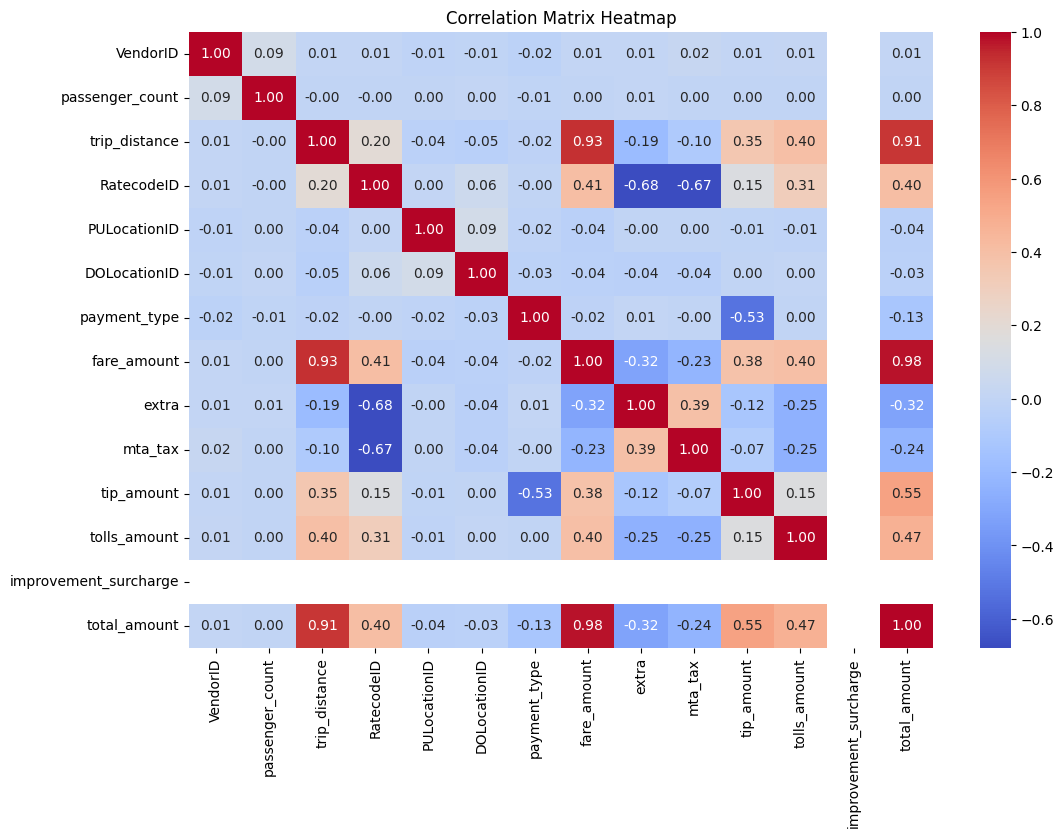

In [ ]:
df_correl = df_taxi_clean.limit(50000).toPandas()

# Correlation Matrix and Heatmap
correlation_matrix = df_correl.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

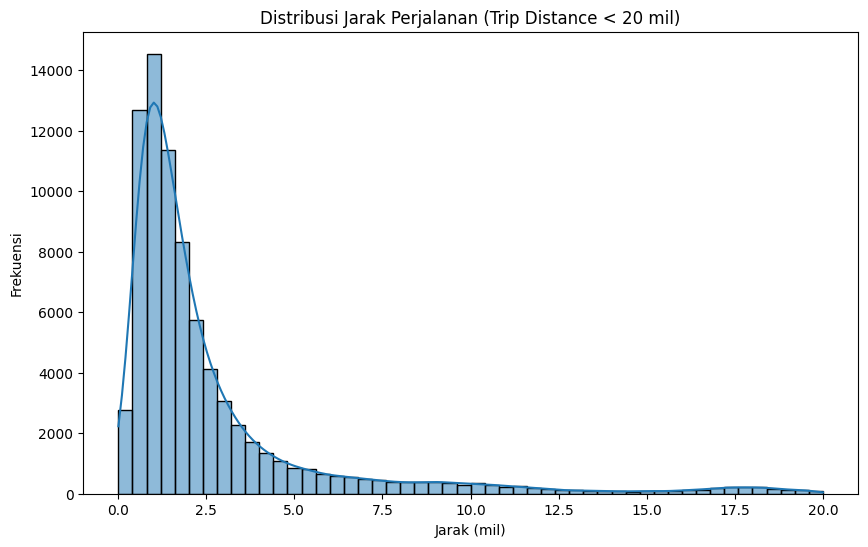

In [ ]:
# Untuk EDA, kita akan bekerja dengan sampel data agar proses visualisasi lebih cepat.
# Ekstrak komponen waktu terlebih dahulu dari data yang sudah bersih.
df_eda_prep = df_taxi_clean.withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
                           .withColumn("pickup_dayofweek", dayofweek("tpep_pickup_datetime"))

# Ambil sampel acak sebesar 1% dari data dan konversi ke Pandas DataFrame
df_eda = df_eda_prep.sample(False, 0.01, seed=42).toPandas()

# Mapping hari dalam seminggu dan tipe pembayaran agar label pada plot lebih mudah dibaca
day_map = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
df_eda['pickup_dayofweek_str'] = df_eda['pickup_dayofweek'].map(day_map)

payment_map = {1: 'Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
df_eda['payment_type_str'] = df_eda['payment_type'].map(payment_map)

"""### Distribusi Jarak Perjalanan (Trip Distance)"""

# Plotting distribusi jarak perjalanan
# Kita filter untuk jarak di bawah 20 mil agar grafik lebih representatif dan mudah dibaca
plt.figure(figsize=(10, 6))
sns.histplot(df_eda[df_eda['trip_distance'] < 20]['trip_distance'], bins=50, kde=True)
plt.title('Distribusi Jarak Perjalanan (Trip Distance < 20 mil)')
plt.xlabel('Jarak (mil)')
plt.ylabel('Frekuensi')
plt.show()

Grafik Distribusi Jarak Perjalanan: Grafik ini menunjukkan bahwa mayoritas perjalanan taksi adalah untuk jarak pendek (sekitar 1-3 mil), sementara perjalanan jarak jauh lebih jarang terjadi.

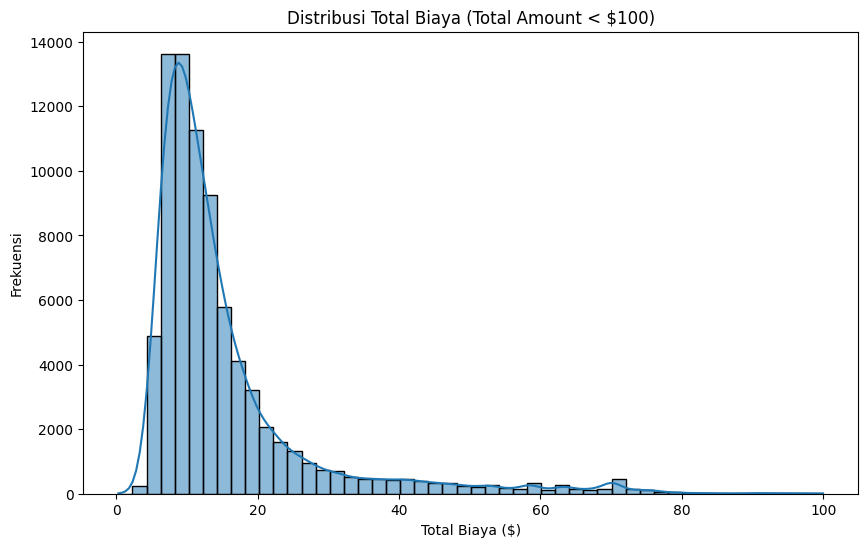

In [ ]:
"""### Distribusi Total Biaya (Total Amount)"""

# Plotting distribusi total biaya
# Kita filter untuk biaya di bawah $100 untuk fokus pada mayoritas transaksi
plt.figure(figsize=(10, 6))
sns.histplot(df_eda[df_eda['total_amount'] < 100]['total_amount'], bins=50, kde=True)
plt.title('Distribusi Total Biaya (Total Amount < $100)')
plt.xlabel('Total Biaya ($)')
plt.ylabel('Frekuensi')
plt.show()

Grafik Distribusi Total Biaya: Grafik ini memperlihatkan bahwa biaya perjalanan paling umum adalah relatif rendah (sekitar $5-$15), yang sesuai dengan banyaknya perjalanan jarak pendek. Adanya puncak kecil di sekitar $50-$60 mengindikasikan adanya tarif tetap (misalnya ke bandara).

<ipython-input-84-717534439>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='pickup_dayofweek_str', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], palette='rocket')


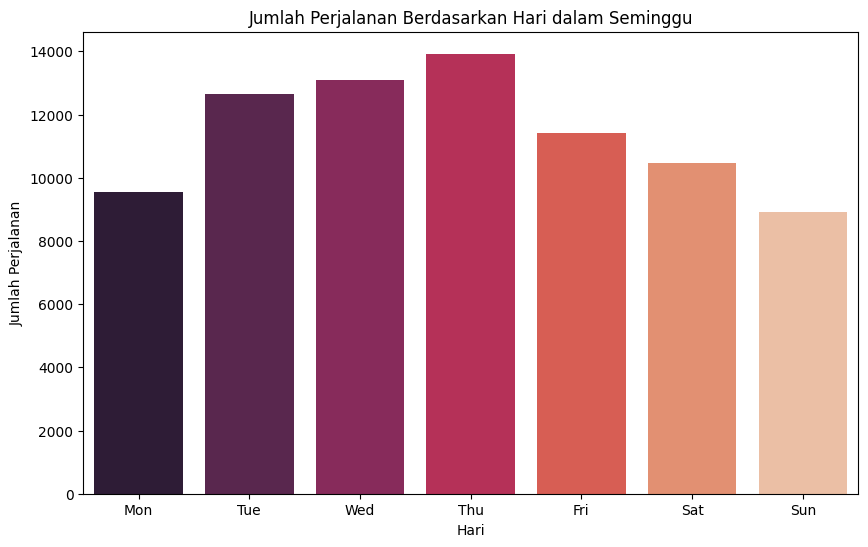

In [ ]:
"""### Jumlah Perjalanan Berdasarkan Jam dan Hari"""

# Bar chart untuk jumlah perjalanan per hari
plt.figure(figsize=(10, 6))
sns.countplot(data=df_eda, x='pickup_dayofweek_str', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], palette='rocket')
plt.title('Jumlah Perjalanan Berdasarkan Hari dalam Seminggu')
plt.xlabel('Hari')
plt.ylabel('Jumlah Perjalanan')
plt.show()

Grafik Jumlah Perjalanan Berdasarkan Hari: Grafik ini menampilkan pola mingguan, di mana jumlah perjalanan tertinggi terjadi pada hari kerja (puncaknya hari Kamis) dan menurun drastis pada akhir pekan (Sabtu dan Minggu).

<ipython-input-86-981591707>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='payment_type_str', order=['Card', 'Cash', 'No Charge'], palette='rocket')


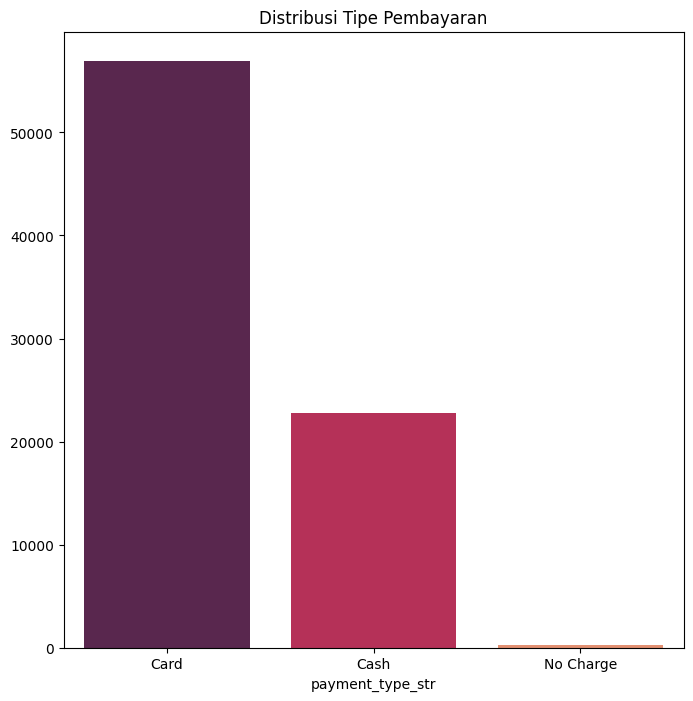

In [ ]:
"""### Distribusi Tipe Pembayaran"""

# Pie chart untuk distribusi tipe pembayaran
plt.figure(figsize=(8, 8))
payment_counts = df_eda['payment_type_str'].value_counts()
sns.countplot(data=df_eda, x='payment_type_str', order=['Card', 'Cash', 'No Charge'], palette='rocket')
plt.title('Distribusi Tipe Pembayaran')
plt.ylabel('')
plt.show()

Grafik Distribusi Tipe Pembayaran: Grafik ini menunjukkan bahwa metode pembayaran yang paling dominan adalah menggunakan kartu (Card), diikuti oleh uang tunai (Cash). Metode lainnya sangat jarang digunakan.

# Langkah 3: Agregasi Data

In [ ]:
#Aggregasi 1 PULocationID
agg_pickup_location = df_taxi_clean.groupBy("PULocationID").agg(
    avg("fare_amount").alias("avg_fare"),
    avg("tip_amount").alias("avg_tip"),
    avg("total_amount").alias("avg_total"),
    count("*").alias("total_trips"),
    sum("passenger_count").alias("total_passengers"),
    avg("trip_distance").alias("avg_distance")
)
agg_pickup_location = agg_pickup_location.orderBy('PULocationID')
agg_pickup_location.show()

+------------+------------------+--------------------+------------------+-----------+----------------+------------------+
|PULocationID|          avg_fare|             avg_tip|         avg_total|total_trips|total_passengers|      avg_distance|
+------------+------------------+--------------------+------------------+-----------+----------------+------------------+
|           1| 76.47028776978416|  10.828992805755398| 93.37733812949641|        139|             207| 7.437194244604316|
|           2| 40.75416666666667|   4.235833333333333| 48.07666666666666|         12|              14|11.543333333333331|
|           3| 32.15417582417582| 0.26554945054945056| 35.60049450549449|        182|             279|10.374175824175824|
|           4|11.626231677814147|   1.483803899245768|14.446129927422781|      14054|           22611|2.6642329585883022|
|           5|            74.375|                 0.0|            81.185|          4|               5|             25.12|
|           6|18.8064516

In [ ]:
#Agregasi 2 Pickup_dayofweek
df_time = df_taxi_clean.withColumn("pickup_date", to_date("tpep_pickup_datetime")) \
            .withColumn("pickup_hour", hour("tpep_pickup_datetime")) \
            .withColumn("pickup_dayofweek", dayofweek("tpep_pickup_datetime")) \
            .withColumn("pickup_month", month("tpep_pickup_datetime"))

agg_date = df_time.groupBy("pickup_date").agg(count("*").alias("trips_per_day"))
agg_hour = df_time.groupBy("pickup_hour").agg(avg("total_amount").alias("avg_total_per_hour"))
agg_dayofweek = df_time.groupBy("pickup_dayofweek").agg(count("*").alias("trips_by_day"),avg("trip_distance").alias("AVG Trip Distance"),avg("total_amount").alias("avg_day_revenue"))
agg_month = df_time.groupBy("pickup_month").agg(avg("total_amount").alias("monthly_revenue"),sum("trip_distance").alias("Total Trip Distance"))

agg_dayofweek = agg_dayofweek.orderBy("pickup_dayofweek")
agg_dayofweek.show()

+----------------+------------+------------------+------------------+
|pickup_dayofweek|trips_by_day| AVG Trip Distance|   avg_day_revenue|
+----------------+------------+------------------+------------------+
|               1|      879863| 3.012654924687134|15.233051816013745|
|               2|      966758| 2.893053514943768|15.624397356923742|
|               3|     1262697|2.8828339340317077| 15.83739326217801|
|               4|     1296969| 2.812555126606739|15.760805177277646|
|               5|     1387991|2.7794782531010918|15.842798224174516|
|               6|     1129083|2.8058766804565844|16.303973064847682|
|               7|     1035180|2.6630007824726247|14.479354218575768|
+----------------+------------+------------------+------------------+



In [ ]:
#Agregasi 3 rate_code_id
agg_rate_code_id = df_taxi_clean.groupBy("RatecodeID").agg(
    avg("fare_amount").alias("avg_fare"),
    avg("tip_amount").alias("avg_tip"),
    avg("total_amount").alias("avg_total"),
    count("*").alias("total_trips"),
    sum("passenger_count").alias("total_passengers"),
    avg("trip_distance").alias("avg_distance")
)
agg_rate_code_id = agg_rate_code_id.orderBy('RatecodeID')
agg_rate_code_id.show()

+----------+-----------------+------------------+------------------+-----------+----------------+------------------+
|RatecodeID|         avg_fare|           avg_tip|         avg_total|total_trips|total_passengers|      avg_distance|
+----------+-----------------+------------------+------------------+-----------+----------------+------------------+
|         1|11.11728399848225|1.6678323230711911|14.221429796325085|    7740397|        12248565|2.4520861617304015|
|         2|52.00189058098537| 8.195012467897469| 66.55694744829535|     160813|          265986|17.364116955718806|
|         3|66.76655333506358|10.704330824465774| 92.17770049312138|      11559|           19157| 17.45562072843671|
|         4|70.61380083618396| 7.786271379703536| 82.30007601672416|       5262|            8442|18.743378943367528|
|         5|44.57917395169665| 2.485881612090677| 50.52728799328223|      40494|           46283|10.996230305724284|
|         6|       419.196875|           0.04125| 420.0381250000

# Langkah 4: Data Streaming

## 4.1 Inisialisasi SparkSession

In [ ]:
!apt-get install openjdk-11-jdk -y
!wget -q https://downloads.apache.org/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz
!pip install -q findspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

import findspark
findspark.init()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra libatk-wrapper-java
  libatk-wrapper-java-jni libxt-dev libxtst6 libxxf86dga1 openjdk-11-jre
  x11-utils
Suggested packages:
  libxt-doc openjdk-11-demo openjdk-11-source visualvm mesa-utils
The following NEW packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra libatk-wrapper-java
  libatk-wrapper-java-jni libxt-dev libxtst6 libxxf86dga1 openjdk-11-jdk
  openjdk-11-jre x11-utils
0 upgraded, 10 newly installed, 0 to remove and 35 not upgraded.
Need to get 6,920 kB of archives.
After this operation, 16.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Get:3 http://archive.ubuntu.com/ubuntu jam

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

spark = SparkSession.builder \
    .appName("Streaming_NYC_Taxi") \
    .master("local[*]") \
    .getOrCreate()

## 4.2 Membuat Folder Streaming

In [ ]:
# Buat folder input dan output
input_path = "/content/input_streaming"
output_path = "/content/output_streaming"
checkpoint_path = "/content/checkpoint"

os.makedirs(input_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)
os.makedirs(checkpoint_path, exist_ok=True)

## 4.3 Siapkan Skema Dataset

In [ ]:
from pyspark.sql.types import StructType, StringType, DoubleType

schema = StructType() \
    .add("VendorID", StringType()) \
    .add("tpep_pickup_datetime", StringType()) \
    .add("tpep_dropoff_datetime", StringType()) \
    .add("passenger_count", StringType()) \
    .add("trip_distance", DoubleType()) \
    .add("RatecodeID", StringType()) \
    .add("store_and_fwd_flag", StringType()) \
    .add("PULocationID", StringType()) \
    .add("DOLocationID", StringType()) \
    .add("payment_type", StringType()) \
    .add("fare_amount", DoubleType()) \
    .add("extra", DoubleType()) \
    .add("mta_tax", DoubleType()) \
    .add("tip_amount", DoubleType()) \
    .add("tolls_amount", DoubleType()) \
    .add("improvement_surcharge", DoubleType()) \
    .add("total_amount", DoubleType())

## 4.4 Baca Streaming CSV

In [ ]:
# Baca file streaming
df_stream = spark.readStream \
    .format("csv") \
    .option("header", "true") \
    .schema(schema) \
    .load(input_path)

In [ ]:
# Simpan ke folder
query = df_stream.writeStream \
    .format("csv") \
    .option("header", "true") \
    .outputMode("append") \
    .option("checkpointLocation", checkpoint_path) \
    .option("path", output_path) \
    .start()

## 4.5 Kirim Data Simulasi ke Folder Input

In [ ]:
import pandas as pd
from pyspark.sql.functions import monotonically_increasing_id

df1 = df_taxi_clean.limit(1000).toPandas()

# Simpan ke CSV tanpa index
df1.to_csv(f"{input_path}/sample1.csv", index=False)

# Cek file
df_check1 = spark.read.csv(f"{input_path}/sample1.csv", header=True)
print(f"Jumlah baris di sample1.csv: {df_check1.count()}")

Jumlah baris di sample1.csv: 1000


## 4.6 Tampilkan Hasil Streaming Output

In [ ]:
import glob
import time
import pandas as pd

time.sleep(10) # Tunggu spark menulis batch

# Ambil semua file output dari streaming
file_list = sorted(glob.glob(f"{output_path}/*.csv"))

if file_list:
  df_result = pd.read_csv(file_list[-1])
  display(df_result)
else:
  print("Tidak ada file output yang ditemukan.")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.50,1,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.60,1,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30
2,1,2019-01-01 00:21:28,2019-01-01 00:28:37,1,1.30,1,N,163,229,1,6.5,0.5,0.5,1.25,0.0,0.3,9.05
3,1,2019-01-01 00:32:01,2019-01-01 00:45:39,1,3.70,1,N,229,7,1,13.5,0.5,0.5,3.70,0.0,0.3,18.50
4,1,2019-01-01 00:57:32,2019-01-01 01:09:32,2,2.10,1,N,141,234,1,10.0,0.5,0.5,1.70,0.0,0.3,13.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2,2019-01-01 00:26:33,2019-01-01 01:00:09,2,2.44,1,N,68,100,1,20.5,0.5,0.5,6.54,0.0,0.3,28.34
996,2,2019-01-01 00:42:18,2019-01-01 00:49:07,1,0.75,1,N,113,249,1,6.0,0.5,0.5,1.10,0.0,0.3,8.40
997,2,2019-01-01 00:50:24,2019-01-01 00:59:03,1,1.10,1,N,249,249,1,7.5,0.5,0.5,1.76,0.0,0.3,10.56
998,2,2019-01-01 00:38:07,2019-01-01 00:51:56,2,3.29,1,N,141,166,2,12.5,0.5,0.5,0.00,0.0,0.3,13.80


In [ ]:
# !cat /content/input_streaming/sample1.csv
# !cat /content/input_streaming/sample2.csv

# Langkah 5: Menyaring dan Membersihkan Data Hasil Data Streaming

In [ ]:
import time
import os

# Path ke folder output streaming
output_path = "/content/output_streaming"

# Path untuk menyimpan file CSV gabungan
combined_output_path = "/content/combined_streaming_output"

# Beri jeda waktu untuk memastikan Spark selesai menulis file
time.sleep(10) # Sesuaikan waktu sesuai kebutuhan, tergantung ukuran data dan kinerja

# Baca semua file CSV dari folder output streaming ke dalam DataFrame PySpark
# Menggunakan skema yang sudah didefinisikan sebelumnya
df_streaming_output = spark.read \
    .format("csv") \
    .option("header", "true") \
    .schema(schema) \
    .load(output_path)

# Gabungkan DataFrame menjadi 1 partisi dan tulis sebagai satu file CSV
# Use mode("overwrite") to handle cases where the combined file already exists
df_streaming_output.coalesce(1).write \
    .format("csv") \
    .option("header", "true") \
    .mode("overwrite") \
    .save(combined_output_path)

print(f"File CSV gabungan telah disimpan di: {combined_output_path}")

File CSV gabungan telah disimpan di: /content/combined_streaming_output


## 5.1 Memeriksa Nilai Null (Missing Values)

In [ ]:
from pyspark.sql.functions import count, when, isnull
import os

combined_output_path = "/content/combined_streaming_output"

df_combined = spark.read.csv(combined_output_path, header=True, inferSchema=True)

# Mengecek jumlah nilai null di setiap kolom
df_combined.select([count(when(isnull(c), c)).alias(c) for c in df_combined.columns]).show()
df_combined.describe().show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       0|                   0|                    0|              0|            0|         0|                 0|           0|           0|           0|          0|    0|      0|         0|           0|                    0|           0|
+--------+--------------------+-----------------

# Langkah 6: Model Machine Learning

In [ ]:
df_combined.show(200)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|              1|          1.5|         1|                 N|         151|         239|           1|        7.0|  0.5|    0.5|      1.65|         0.0|                  0.3|        9.95|
|       1| 2019-01-01 00:59:47|  2019-01-01 01:1

## 6.1 Hitung price_per_meter dalam dollar

In [ ]:
from pyspark.sql.functions import col

# Ubah trip_distance menjadi dalam satuan meter dan hitung price_per_meter
df = df_combined.withColumn("trip_distance_meter", col("trip_distance") * 1609) \
                  .withColumn("price_per_meter", col("total_amount") / col("trip_distance_meter")) \
                  .withColumn("trip_distance_kilometer", col("trip_distance_meter") / 1000)

df.show(10)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+--------------------+-----------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|trip_distance_meter|     price_per_meter|trip_distance_kilometer|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+--------------------+-----------------------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|              1|          1.5|        

## 6.2 Tambahkan Kolom pickup_hour dan pickup_day

In [ ]:
from pyspark.sql.functions import hour, dayofweek

df = df.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
df = df.withColumn("pickup_day", dayofweek("tpep_pickup_datetime"))

df.show(10)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+--------------------+-----------------------+-----------+----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|trip_distance_meter|     price_per_meter|trip_distance_kilometer|pickup_hour|pickup_day|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+--------------------+-----------------------+-----------+----------+
|       1| 2019-01-01 

## 6.3 Preprocessing dan Feature Engineering

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# StringIndexer untuk kolom kategorikal
indexer_store = StringIndexer(inputCol="store_and_fwd_flag", outputCol="fwd_index")

# Fitur yang digunakan untuk prediksi
feature_cols = [
    "VendorID", "passenger_count", "trip_distance",
    "RatecodeID", "PULocationID", "DOLocationID",
    "payment_type", "total_amount", "pickup_hour",
    "pickup_day", "fwd_index"
]

# Gabungkan ke dalam vektor fitur
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

## 6.4 Model: Gradient Boosted Tree Regressor

In [ ]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(featuresCol="features", labelCol="price_per_meter", maxIter=50)

pipeline = Pipeline(stages=[indexer_store, assembler, gbt])

## 6.5 Train/Test Split dan Training

In [ ]:
from pyspark.sql.functions import isnan, col

# Drop baris dengan nilai null or NaN pada kolom price_per_meter
df_cleaned_for_model = df.filter((col("price_per_meter").isNotNull()) & (~isnan(col("price_per_meter"))))

train_data, test_data = df_cleaned_for_model.randomSplit([0.8, 0.2], seed=42)
model = pipeline.fit(train_data)

## 6.6 Evaluasi Model

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

predictions = model.transform(test_data)

evaluator_rmse = RegressionEvaluator(labelCol="price_per_meter", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price_per_meter", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"✅ RMSE: {rmse:.6f} detik")
print(f"✅ R² Score: {r2:.4f}")

✅ RMSE: 0.001604 detik
✅ R² Score: 0.6235


## 6.7 Visualisasikan Hasil Prediksi vs Aktual (price_per_meter)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


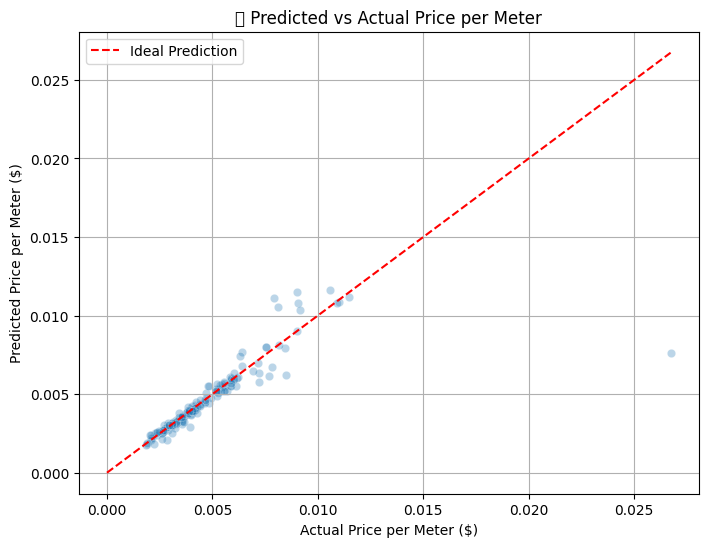

In [ ]:
# Ambil hanya kolom yang dibutuhkan
pred_df = predictions.select("prediction", "price_per_meter")

# Convert ke Pandas
pred_pd = pred_df.sample(False, 1.0, seed=42).toPandas()  # ambil 100% sample
pred_pd.to_csv("pred_pd.csv", index=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pred_pd, x="price_per_meter", y="prediction", alpha=0.3)

plt.xlabel("Actual Price per Meter ($)")
plt.ylabel("Predicted Price per Meter ($)")
plt.title("📊 Predicted vs Actual Price per Meter")
plt.grid(True)
plt.plot([0, pred_pd["price_per_meter"].max()],
         [0, pred_pd["price_per_meter"].max()],
         color='red', linestyle='--', label='Ideal Prediction')
plt.legend()
plt.show()

In [ ]:
from pyspark.sql.functions import monotonically_increasing_id

df_gbt = predictions.withColumnRenamed("prediction", "predicted_price_per_meter") \
                             .drop("features")

df_with_id = df_gbt.withColumn("orderID", monotonically_increasing_id())

df_gbt_final = df_with_id.select("orderID", *df_gbt.columns)

# Tampilkan beberapa baris hasil untuk verifikasi
print("Menampilkan DataFrame:")
df_gbt_final.show()

# Simpan DataFrame bersih ke dalam satu file CSV
df_gbt_final.coalesce(1).write.csv("df_gbt_final.csv", header=True, mode="overwrite")

print("File 'df_gbt_final.csv' telah berhasil disimpan.")

Menampilkan DataFrame:
+-------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+--------------------+-----------------------+-----------+----------+---------+-------------------------+
|orderID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|trip_distance_meter|     price_per_meter|trip_distance_kilometer|pickup_hour|pickup_day|fwd_index|predicted_price_per_meter|
+-------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+-----

# Langkah 7: Model Machine Learning Linier Regression

## 7.1 Persiapan

In [ ]:
# Ubah trip_distance menjadi dalam satuan meter dan hitung price_per_meter
df2 = df_combined.withColumn("trip_distance_meter", col("trip_distance") * 1609) \
                  .withColumn("price_per_meter", col("total_amount") / col("trip_distance_meter"))

# StringIndexer untuk kolom kategorikal
indexer_store = StringIndexer(inputCol="store_and_fwd_flag", outputCol="fwd_index")

# Fitur yang digunakan untuk prediksi
feature_cols = [
    "VendorID", "passenger_count", "trip_distance",
    "RatecodeID", "PULocationID", "DOLocationID",
    "payment_type", "total_amount", "pickup_hour",
    "pickup_day", "fwd_index"
]

# Gabungkan ke dalam vektor fitur
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

from pyspark.ml.regression import LinearRegression
# Inisialisasi Linier Regression
lr = LinearRegression(featuresCol="features", labelCol="price_per_meter")

# Buat pipeline
pipeline2 = Pipeline(stages=[indexer_store, assembler, lr])

## 7.2 Train/Test Split dan Training

In [ ]:
# Drop baris dengan nilai null or NaN pada kolom price_per_meter
df_cleaned_for_model = df.filter((col("price_per_meter").isNotNull()) & (~isnan(col("price_per_meter"))))

train_data2, test_data2 = df_cleaned_for_model.randomSplit([0.8, 0.2], seed=42)

# Latih model
model2 = pipeline2.fit(train_data2)

## 7.3 Evaluasi Model

In [ ]:
predictions2 = model2.transform(test_data2)

evaluator_rmse2 = RegressionEvaluator(
    labelCol="price_per_meter",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_r22 = RegressionEvaluator(
    labelCol="price_per_meter",
    predictionCol="prediction",
    metricName="r2"
)

rmse2 = evaluator_rmse2.evaluate(predictions2)
r22 = evaluator_r22.evaluate(predictions2)

print(f"✅ RMSE: {rmse2:.6f} $/meter")
print(f"✅ R² Score: {r22:.4f}")

✅ RMSE: 0.002319 $/meter
✅ R² Score: 0.2126


## 7.4 Visualisasikan Hasil Prediksi vs Aktual (price_per_meter)

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


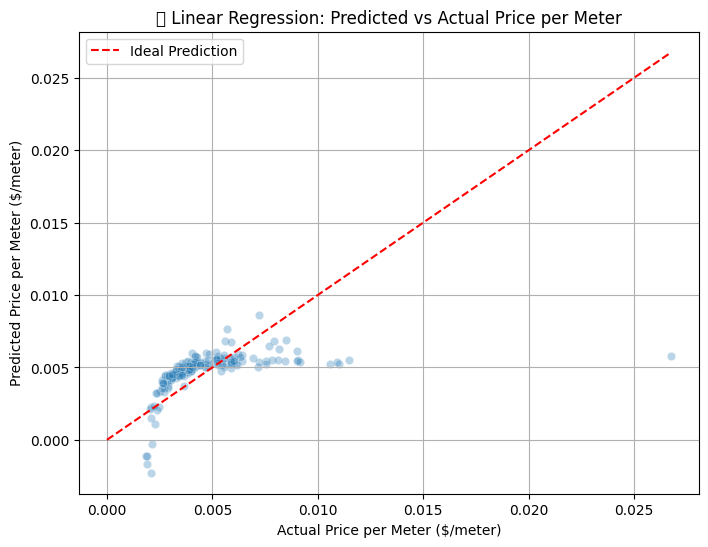

In [ ]:
pred_df2 = predictions2.select("prediction", "price_per_meter")

# Convert ke Pandas untuk visualisasi
pred_pd2 = pred_df2.sample(False, 1.0, seed=42).toPandas()
pred_pd2.to_csv("pred_pd2.csv", index=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pred_pd2, x="price_per_meter", y="prediction", alpha=0.3)

plt.xlabel("Actual Price per Meter ($/meter)")
plt.ylabel("Predicted Price per Meter ($/meter)")
plt.title("📊 Linear Regression: Predicted vs Actual Price per Meter")
plt.grid(True)

# Garis ideal
max_val = max(pred_pd2["price_per_meter"].max(), pred_pd2["prediction"].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Ideal Prediction')
plt.legend()

plt.show()

In [ ]:
from pyspark.sql.functions import monotonically_increasing_id

df_linreg = predictions2.withColumnRenamed("prediction", "predicted_price_per_meter") \
                             .drop("features")

df_with_id2 = df_linreg.withColumn("orderID", monotonically_increasing_id())

df_linreg_final = df_with_id2.select("orderID", *df_linreg.columns)

# Tampilkan beberapa baris hasil untuk verifikasi
print("Menampilkan DataFrame:")
df_linreg_final.show()

# Simpan DataFrame bersih ke dalam satu file CSV
df_linreg_final.coalesce(1).write.csv("df_linreg_final.csv", header=True, mode="overwrite")

print("File 'df_linreg_final.csv' telah berhasil disimpan.")

Menampilkan DataFrame:
+-------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+-------------------+--------------------+-----------------------+-----------+----------+---------+-------------------------+
|orderID|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|trip_distance_meter|     price_per_meter|trip_distance_kilometer|pickup_hour|pickup_day|fwd_index|predicted_price_per_meter|
+-------+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+-----